In [1]:
import numpy as np
import matplotlib.pyplot as plt


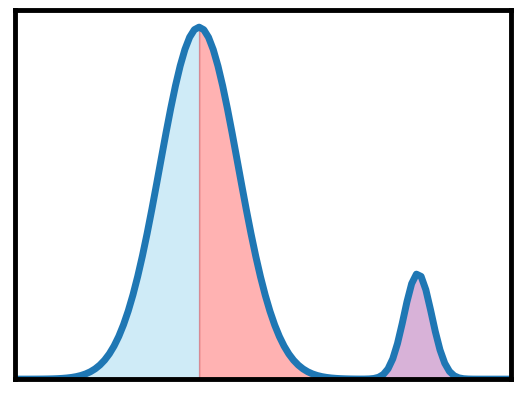

In [2]:
x_neg_lim = -1.51
x_pos_lim = 2.50234
x = np.linspace(x_neg_lim, x_pos_lim, 106)
y = np.exp(-(x+0.02)**2/0.2) + 0.3*np.exp(-(x-1.75)**2/0.025)

fig, ax = plt.subplots()
plt.plot(x, y, lw = 5)
plt.yticks([])
plt.xticks([])
plt.xlim([x_neg_lim, x_pos_lim])
plt.ylim([0,1.05])
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_linewidth(3.5)

plt.fill_between(x[x<0.01], y[x<0.01], color='skyblue', alpha=0.4) 
plt.fill_between(x[np.logical_and(x>-0.03, x<1.5)], y[np.logical_and(x>-0.03, x<1.5)], color='red', alpha=0.3) 

plt.fill_between(x[x>1.45], y[x>1.45], color='purple', alpha=0.3) 

In [3]:
which_plot = 3
if which_plot == 0:
    thresh = -0.7
if which_plot == 1:
    thresh = -0.7


x = np.random.uniform(thresh, 1, [2, 100])
if which_plot == 3:
    x = np.array([[0, 0, 0, 0, 0, 1, 1], [0, 0, 0, 0, 1, 1, 1]])
if which_plot == 4:
    x = np.array([[0, 0, 0, 1, 0], [0, 0, 0, 0, 1]])

# For the very correlated example
if which_plot == 2:        
    x[0,:] = x[1,:] + np.random.normal(0, 0.2, x.shape[1])
    x = np.hstack([x, np.array([[-1, 1], [1,-1]])])
    
x = np.maximum(x, np.zeros(x.shape))
x[1,:] *= np.max(x[0,:])/np.max(x[1,:])
x = x - np.mean(x, axis = 1)[:,None]
x = x/np.abs(np.min(x, axis = 1)[:,None])
if which_plot == 1:
    x = np.delete(x, np.logical_and(x[0,:] < 0, x[1,:] < 0), axis = 1)

              
for dim in range(2):
    if np.abs(np.min(x[dim,:])) > np.max(x[dim,:]):
        x[:,dim] *= -1



x[1,:] *= np.max(x[0,:])/np.max(x[1,:])
x = x - np.mean(x, axis = 1)[:,None]
x = x/np.abs(np.min(x, axis = 1)[:,None])

NameError: name 'thresh' is not defined

In [10]:
x = np.load('x_example_fig_1_c.npy')

x = np.array([[0, 0, 0, 1], [0, 0, 1, 0]])
x = x - np.mean(x, axis = 1)[:,None]
x = x/np.abs(np.min(x, axis = 1)[:,None])

array([ True,  True, False, False])

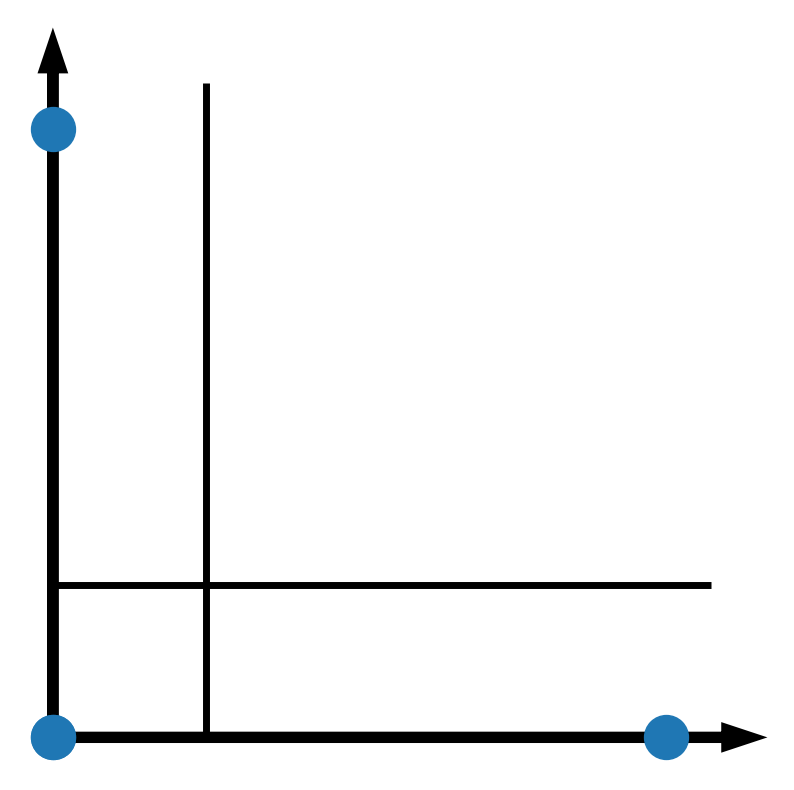

In [11]:
fig, ax = plt.subplots(figsize = (10,10))
plt.scatter(x[0,:], x[1,:], s = 1000)
for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_linewidth(0)

plt.arrow(-1, -1, (np.max(x[0,:])+1)*1.1, 0, lw = 8, head_width = 0.1, zorder = -1)
plt.arrow(-1, -1, 0, (np.max(x[1,:])+1)*1.1, lw = 8, head_width = 0.1, zorder = -1)

plt.vlines(0, np.max(x[1,:])*1.1, -1, lw = 5, colors = 'k', zorder = -2)
plt.hlines(0, np.max(x[0,:])*1.1, -1, lw = 5, colors = 'k', zorder = -2)

ax.spines['left'].set_position('zero')
ax.spines['bottom'].set_position('zero')
plt.yticks([])
plt.xticks([])

np.logical_and(x[0,:] < 1, x[1,:] < 1)

In [252]:
np.save('x_example_fig_1_c.npy', x)

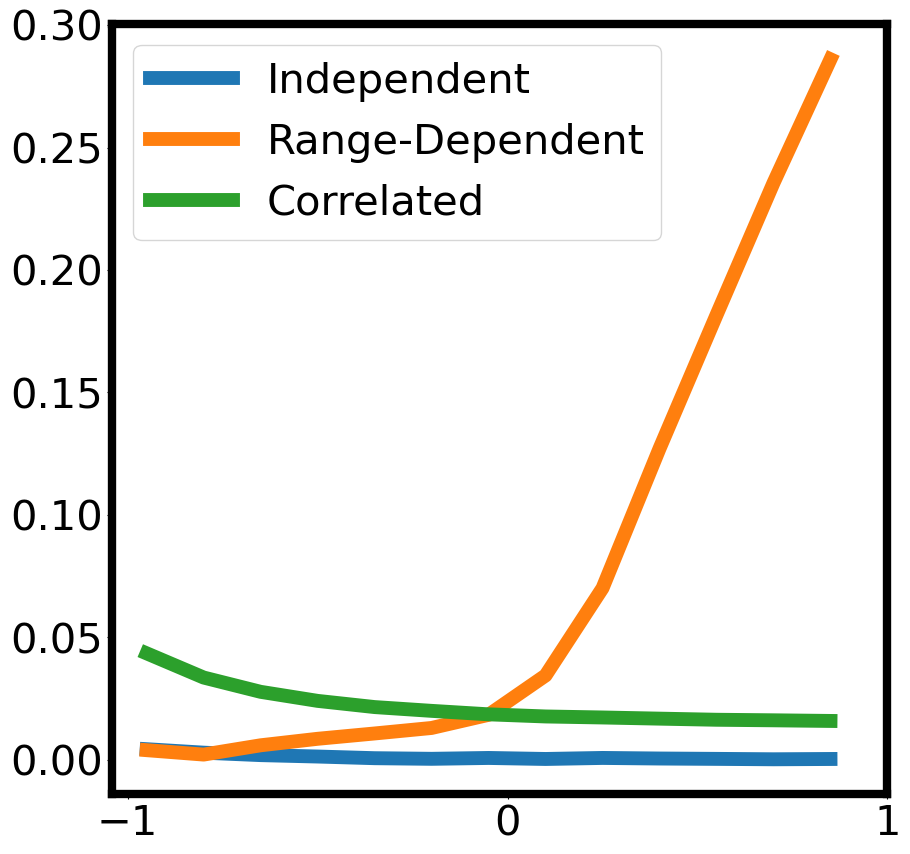

In [290]:
modularity_a = np.load('modularity_index_a.npy')
modularity_b = np.load('modularity_index_b.npy')
modularity_c = np.load('modularity_index_c.npy')
thetas = np.arange(-0.95, 0.95, 0.15)


fig, ax = plt.subplots(figsize = (10,10))
plt.plot(thetas, modularity_a, lw = 10, label = 'Independent')
plt.plot(thetas, modularity_b, lw = 10, label = 'Range-Dependent')
plt.plot(thetas, modularity_c, lw = 10, label = 'Correlated')

plt.legend(fontsize = 30)

for side in ['top', 'bottom', 'left', 'right']:
    ax.spines[side].set_linewidth(6)

#plt.yticks([0, 0.3])
plt.xticks([-1, 0, 1])

ax.tick_params(axis='both', labelsize=30)


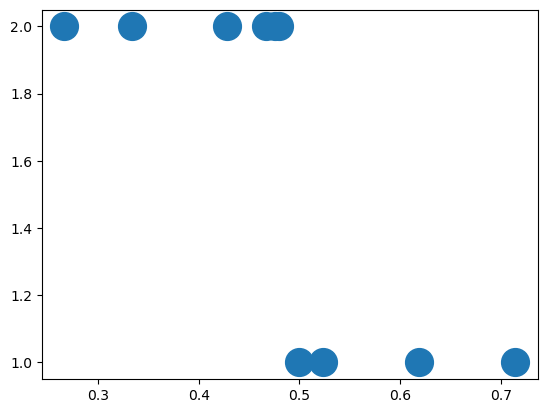

In [306]:
sparsity = [0.7142857142857143, 0.6190476190476191, 0.5238095238095238, 0.48, 0.5, 0.47619047619047616, 0.4666667, 0.42857142857142855, 0.3333333333333333, 0.26666668]

num_neurons = [1, 1, 1, 2, 1, 2, 2, 2, 2, 2]

plt.plot(sparsity, num_neurons, 'o', ms = 20)